In [1]:
import pandas as pd
import re
import torch

#libraries for data explore
import seaborn as sns
import matplotlib.pyplot as plt

#libraries for Model training and evaluation
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

/opt/anaconda3/lib/python3.13/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/anaconda3/lib/python3.13/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/anaconda3/lib/python3.13/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [2]:
# Example: Load a CSV dataset
df = pd.read_csv("phishing_email.csv")


df.shape

(82486, 2)

In [3]:
# Randomly sample 15,000 rows from the full dataset
df = df.sample(n=15000, random_state=42).reset_index(drop=True)

print(df.head())

                                       text_combined  label
0  endangered languages workshop foundation endan...      0
1  claretta claretta_bordersfusemailcom cialis wo...      1
2  roger upole schkeramsncom kyle rickey wrote im...      0
3  barclays customer service testlightworldcojp d...      1
4  gmm 09 nov 2001 please find attached global ma...      0


In [4]:
# Remove nulls
df.dropna(inplace=True)

# Convert label
df['label'] = df['label'].astype(int)

# Lowercasing
df['text_combined'] = df['text_combined'].apply(lambda x: x.lower())

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  15000 non-null  object
 1   label          15000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 234.5+ KB
None


In [6]:
df.shape

(15000, 2)

In [7]:
df.tail()

,text_combined,label
14995,winning notification dalobica lotto bv interna...,1
14996,become happy performance girlfriend loves resu...,1
14997,looks good obviously close originally suggest...,0
14998,cnn alerts frakte_1973emmeffenet cnn alerts cu...,1
14999,danny graham ingridchianghadleybuytaertnet syo...,1


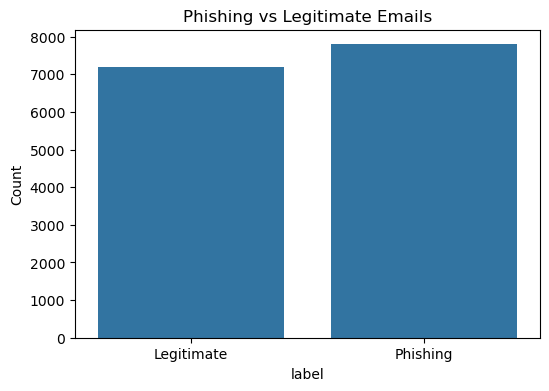

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label') # counts the number of occurrences of each unique value in a column
plt.title('Phishing vs Legitimate Emails')
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.ylabel('Count')
plt.show()

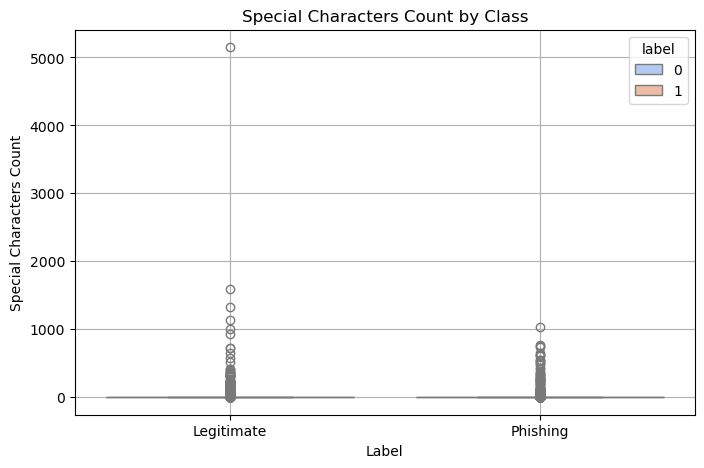

In [9]:
#compare number of special characters in phising vs legitimate emails
df['special_chars'] = df['text_combined'].apply(lambda x: sum(not c.isalnum() and not c.isspace() for c in x))

plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='special_chars', data=df, hue='label', palette='coolwarm', dodge=False)

plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.title('Special Characters Count by Class')
plt.xlabel('Label')
plt.ylabel('Special Characters Count')
plt.grid(True)
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kasmyabhatia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


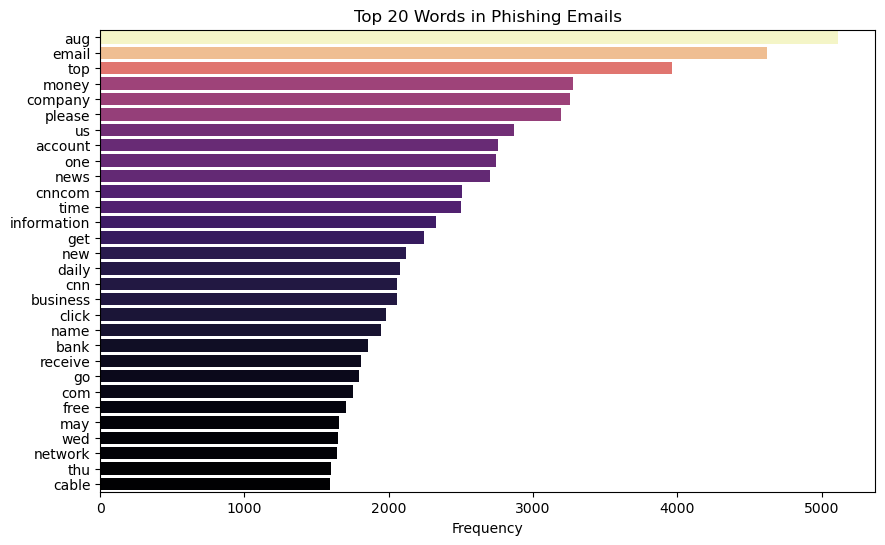

In [10]:
#analyzing common words in phising emails
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


stop_words = set(stopwords.words('english'))  #e.g., "the", "is", "and"

# Combine all phishing emails: Joins all texts into one string → converts to lowercase → splits into words
phishing_words = ' '.join(df[df['label']==1]['text_combined']).lower().split() #Selects only phishing emails (where label == 1)

filtered_words = [word for word in phishing_words if word.isalpha() and word not in stop_words] #Alphabetic words (removes numbers, punctuation)

word_freq = Counter(filtered_words).most_common(30)

# Barplot of top words
words, counts = zip(*word_freq)  #Unpacks the 20 most common word–count pairs into two separate lists: words and counts
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words),hue =list(counts), palette='magma',legend=False)
plt.title('Top 20 Words in Phishing Emails')
plt.xlabel('Frequency')
plt.show()

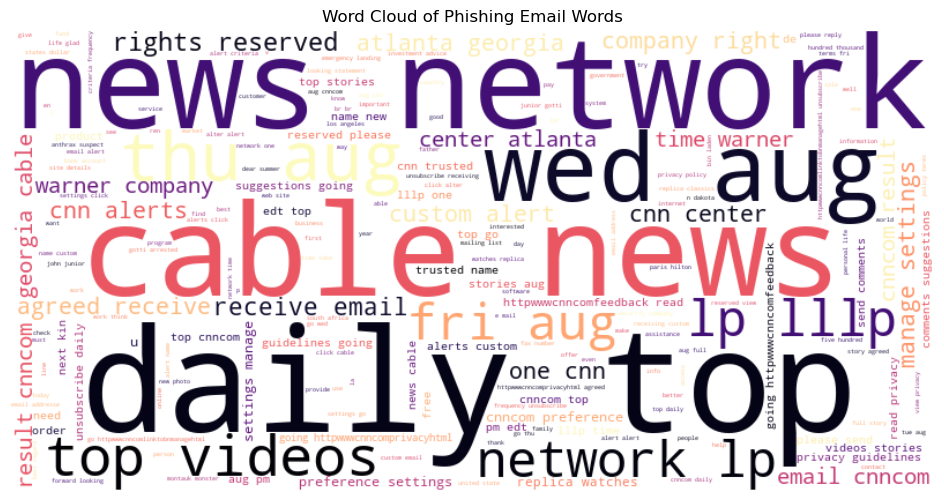

In [11]:
from wordcloud import WordCloud

# Join all filtered phishing words into a single string
wordcloud_text = ' '.join(filtered_words)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Phishing Email Words')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

# 1. First, split out 20% test data

train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(df['text_combined'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42, stratify=df['label'])

# 2. Then split remaining 80% into 70% train and 10% val

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels,
    test_size=0.125,  # 10% of total = 12.5% of the remaining 80%
    random_state=42, stratify=train_val_labels
)

In [13]:
#tokenization using bert tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Tokenize the datasets
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=128
)

/opt/anaconda3/lib/python3.13/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [14]:
print(train_encodings['input_ids'][0])          # View input IDs of the first text
print(train_encodings['attention_mask'][0]) 

[101, 17264, 7027, 2373, 3001, 3204, 3283, 2218, 3116, 5395, 3288, 2362, 3001, 3136, 3293, 2111, 3625, 12697, 2311, 17264, 7027, 3001, 2763, 3174, 2111, 2164, 7014, 2566, 12624, 4938, 2154, 7113, 7014, 10439, 14511, 2080, 3960, 2534, 8886, 17891, 6746, 6927, 3902, 3762, 6754, 24185, 21007, 2063, 7369, 2014, 19333, 6264, 6606, 3889, 14085, 5076, 20105, 16215, 6072, 2050, 5297, 11623, 2928, 27078, 8512, 6519, 10524, 2116, 2048, 17817, 4484, 3116, 2034, 3154, 9129, 2111, 2551, 9033, 10483, 7014, 2177, 3225, 2831, 4938, 2177, 2609, 6337, 2136, 3931, 20105, 9352, 26351, 2014, 19333, 25212, 2015, 4372, 2050, 3043, 2264, 4372, 2050, 2225, 4372, 2050, 3872, 2968, 19387, 2080, 7617, 2111, 3331, 2028, 2178, 2117, 3154, 6343, 2699, 4949, 4072, 4972, 4906, 2362, 13487, 6927, 3902, 3762, 102]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [15]:
#data input format for bert
class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
        
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmailDataset(train_encodings, train_labels)
val_dataset = EmailDataset(val_encodings, val_labels)

In [16]:
#load pretrained bert for classification
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary', zero_division=1
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [18]:
training_args = TrainingArguments(
    output_dir="./results",

    max_steps=300,
    per_device_train_batch_size=8,

    learning_rate=2e-5,
    weight_decay=0.01,
    label_smoothing_factor=0.1,

    evaluation_strategy="steps",
    eval_steps=100,
    load_best_model_at_end=True,

    save_strategy="steps",
    save_steps=100,

    metric_for_best_model="f1",
    greater_is_better=True,

    logging_steps=100,

    report_to="none",
    disable_tqdm=True
)

In [19]:
from accelerate import Accelerator

# Patch to ignore unsupported args like 'dispatch_batches'
class PatchedAccelerator(Accelerator):
    def __init__(self, *args, **kwargs):
        kwargs.pop("dispatch_batches", None)
        super().__init__(*args, **kwargs)

# Inject patch into transformers Trainer
import transformers.trainer
transformers.trainer.Accelerator = PatchedAccelerator

In [20]:
from transformers import Trainer, DataCollatorWithPadding, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [21]:
from torch.utils.data import Subset
import random
'''
# random 2000 samples 
indices = random.sample(range(len(trainer.train_dataset)), 2000)
'''
trainer.train_dataset = train_dataset

In [22]:
'''indices_val = random.sample(range(len(trainer.eval_dataset)), 500)

trainer.eval_dataset = Subset(trainer.eval_dataset, indices_val)'''

trainer.train_dataset = train_dataset  
trainer.eval_dataset = val_dataset 

In [23]:
trainer.train()

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': 0.4612, 'learning_rate': 1.3333333333333333e-05, 'epoch': 0.08}


Checkpoint destination directory ./results/checkpoint-100 already exists and is non-empty.Saving will proceed but saved results may be invalid.


{'eval_loss': 0.32996585965156555, 'eval_accuracy': 0.9206666666666666, 'eval_f1': 0.92018779342723, 'eval_precision': 0.9634831460674157, 'eval_recall': 0.8806161745827985, 'eval_runtime': 18.5651, 'eval_samples_per_second': 80.797, 'eval_steps_per_second': 10.127, 'epoch': 0.08}
{'loss': 0.3014, 'learning_rate': 6.666666666666667e-06, 'epoch': 0.15}


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Checkpoint destination directory ./results/checkpoint-200 already exists and is non-empty.Saving will proceed but saved results may be invalid.


{'eval_loss': 0.28124743700027466, 'eval_accuracy': 0.9553333333333334, 'eval_f1': 0.9570237331622835, 'eval_precision': 0.9564102564102565, 'eval_recall': 0.9576379974326059, 'eval_runtime': 19.2244, 'eval_samples_per_second': 78.026, 'eval_steps_per_second': 9.779, 'epoch': 0.15}
{'loss': 0.2841, 'learning_rate': 0.0, 'epoch': 0.23}


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Checkpoint destination directory ./results/checkpoint-300 already exists and is non-empty.Saving will proceed but saved results may be invalid.


{'eval_loss': 0.2830558717250824, 'eval_accuracy': 0.9526666666666667, 'eval_f1': 0.9538661468486029, 'eval_precision': 0.9657894736842105, 'eval_recall': 0.9422336328626444, 'eval_runtime': 21.3469, 'eval_samples_per_second': 70.268, 'eval_steps_per_second': 8.807, 'epoch': 0.23}
{'train_runtime': 180.6421, 'train_samples_per_second': 13.286, 'train_steps_per_second': 1.661, 'train_loss': 0.3489323616027832, 'epoch': 0.23}


TrainOutput(global_step=300, training_loss=0.3489323616027832, metrics={'train_runtime': 180.6421, 'train_samples_per_second': 13.286, 'train_steps_per_second': 1.661, 'train_loss': 0.3489323616027832, 'epoch': 0.23})

In [24]:
trainer.evaluate()

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.28124743700027466, 'eval_accuracy': 0.9553333333333334, 'eval_f1': 0.9570237331622835, 'eval_precision': 0.9564102564102565, 'eval_recall': 0.9576379974326059, 'eval_runtime': 21.7025, 'eval_samples_per_second': 69.116, 'eval_steps_per_second': 8.663, 'epoch': 0.23}


{'eval_loss': 0.28124743700027466,
 'eval_accuracy': 0.9553333333333334,
 'eval_f1': 0.9570237331622835,
 'eval_precision': 0.9564102564102565,
 'eval_recall': 0.9576379974326059,
 'eval_runtime': 21.7025,
 'eval_samples_per_second': 69.116,
 'eval_steps_per_second': 8.663,
 'epoch': 0.23}

In [25]:
preds = trainer.predict(val_dataset)

import numpy as np
labels = preds.label_ids
predictions = np.argmax(preds.predictions, axis=1)

print("Unique predictions:", set(predictions))
print("Accuracy:", (predictions == labels).mean())

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Unique predictions: {np.int64(0), np.int64(1)}
Accuracy: 0.9553333333333334


In [26]:
train_texts_set = set(train_texts)
val_texts_set = set(val_texts)

overlap = train_texts_set.intersection(val_texts_set)

print("Overlap samples:", len(overlap))

Overlap samples: 3


In [27]:
import numpy as np
from scipy.special import softmax

probs = softmax(preds.predictions, axis=1)
conf = np.max(probs, axis=1)

print("Avg confidence:", np.mean(conf))

Avg confidence: 0.9348039


In [28]:
# Save your trained model and tokenizer
model.save_pretrained("./phishing_model")
tokenizer.save_pretrained("./phishing_model")
print("Model saved successfully to ./phishing_model")

Model saved successfully to ./phishing_model


In [29]:
# ============================================
# OVERFITTING CHECK FOR BERT MODEL
# ============================================

print("\n" + "=" * 60)
print("OVERFITTING DETECTION FOR BERT")
print("=" * 60)

# Get training metrics from trainer history
if hasattr(trainer, 'state') and hasattr(trainer.state, 'log_history'):
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    for log in trainer.state.log_history:
        if 'loss' in log and 'epoch' in log:
            train_losses.append((log['epoch'], log['loss']))
        if 'eval_loss' in log:
            val_losses.append((log['epoch'], log['eval_loss']))
        if 'eval_accuracy' in log:
            val_accs.append((log['epoch'], log['eval_accuracy']))
    
    if len(train_losses) > 0 and len(val_losses) > 0:
        print(f"\nFinal Training Loss: {train_losses[-1][1]:.4f}")
        print(f"Final Validation Loss: {val_losses[-1][1]:.4f}")
        loss_gap = val_losses[-1][1] - train_losses[-1][1]
        print(f"Loss Gap: {loss_gap:.4f}")
        
        if loss_gap > 0.3:
            print("⚠️ WARNING: Large loss gap indicates overfitting!")
        elif loss_gap > 0.1:
            print("⚠️ Possible mild overfitting")
        else:
            print("✅ Loss gap is small - good sign!")


OVERFITTING DETECTION FOR BERT

Final Training Loss: 0.2841
Final Validation Loss: 0.2812
Loss Gap: -0.0029
✅ Loss gap is small - good sign!


In [30]:
# ============================================
# CHECK DATA LEAKAGE
# ============================================
print("\n" + "=" * 60)
print("DATA LEAKAGE CHECK")
print("=" * 60)

# Check exact text overlap
train_texts_set = set(train_texts)
val_texts_set = set(val_texts)
overlap = train_texts_set.intersection(val_texts_set)

print(f"Train samples: {len(train_texts)}")
print(f"Validation samples: {len(val_texts)}")
print(f"Overlap samples: {len(overlap)}")

if len(overlap) > 0:
    print(f"⚠️ WARNING: {len(overlap)} samples appear in both train and validation!")
    print("This causes data leakage and overfitting!")
    
    # Show example of overlapping text
    if len(overlap) > 0:
        print(f"\nExample overlapping text:")
        print(f"  {list(overlap)[0][:200]}...")
else:
    print("✅ No data leakage detected!")

# Check for near-duplicates (similarity > 90%)
from difflib import SequenceMatcher

def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

print("\nChecking for near-duplicates...")
near_duplicates = 0
for i, train_text in enumerate(train_texts[:100]):  # Check first 100
    for val_text in val_texts[:100]:
        if similar(train_text, val_text) > 0.9:
            near_duplicates += 1

if near_duplicates > 10:
    print(f"⚠️ Found {near_duplicates} near-duplicate pairs (>90% similar)")
else:
    print(f"✅ Only {near_duplicates} near-duplicates found")


DATA LEAKAGE CHECK
Train samples: 10500
Validation samples: 1500
Overlap samples: 3
⚠️ WARNING: 3 samples appear in both train and validation!
This causes data leakage and overfitting!

Example overlapping text:
  final version rohm haas added sale union carbide april added...

Checking for near-duplicates...
✅ Only 2 near-duplicates found


In [31]:
# ============================================
# CONFIDENCE CALIBRATION CHECK
# ============================================
print("\n" + "=" * 60)
print("CONFIDENCE CALIBRATION")
print("=" * 60)

from scipy.special import softmax

# Get predictions on validation set
val_preds = trainer.predict(val_dataset)
val_probs = softmax(val_preds.predictions, axis=1)
val_confidences = np.max(val_probs, axis=1)
val_predictions = np.argmax(val_preds.predictions, axis=1)
val_true = val_preds.label_ids

# Calculate confidence for correct vs wrong predictions
correct_conf = [val_confidences[i] for i in range(len(val_confidences)) if val_predictions[i] == val_true[i]]
wrong_conf = [val_confidences[i] for i in range(len(val_confidences)) if val_predictions[i] != val_true[i]]

print(f"Average confidence - Correct predictions: {np.mean(correct_conf):.4f}")
print(f"Average confidence - Wrong predictions: {np.mean(wrong_conf):.4f}")
print(f"Confidence gap: {np.mean(correct_conf) - np.mean(wrong_conf):.4f}")

if np.mean(correct_conf) > 0.95 and len(wrong_conf) > 0:
    print("⚠️ Model is overconfident on correct predictions")
else:
    print("✅ Confidence calibration looks reasonable")

# Check confidence distribution
print(f"\nConfidence distribution:")
print(f"  >95% confident: {sum(1 for c in val_confidences if c > 0.95)}/{len(val_confidences)} ({sum(1 for c in val_confidences if c > 0.95)/len(val_confidences)*100:.1f}%)")
print(f"  50-95% confident: {sum(1 for c in val_confidences if 0.5 <= c <= 0.95)}/{len(val_confidences)}")
print(f"  <50% confident: {sum(1 for c in val_confidences if c < 0.5)}/{len(val_confidences)}")


CONFIDENCE CALIBRATION


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Average confidence - Correct predictions: 0.9401
Average confidence - Wrong predictions: 0.8214
Confidence gap: 0.1187
✅ Confidence calibration looks reasonable

Confidence distribution:
  >95% confident: 907/1500 (60.5%)
  50-95% confident: 593/1500
  <50% confident: 0/1500


In [32]:
# ============================================
# CLASS-WISE PERFORMANCE
# ============================================
print("\n" + "=" * 60)
print("CLASS-WISE PERFORMANCE")
print("=" * 60)

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(val_true, val_predictions)
print("\nConfusion Matrix:")
print(f"                Predicted")
print(f"                Legit  Phish")
print(f"Actual Legit:   {cm[0][0]:5d}  {cm[0][1]:5d}")
print(f"Actual Phish:   {cm[1][0]:5d}  {cm[1][1]:5d}")

# Calculate per-class metrics
tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

legit_precision = tn / (tn + fn) if (tn + fn) > 0 else 0
legit_recall = tn / (tn + fp) if (tn + fp) > 0 else 0
phish_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
phish_recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\nLegitimate Email Performance:")
print(f"  Precision: {legit_precision:.4f}")
print(f"  Recall: {legit_recall:.4f}")

print(f"\nPhishing Email Performance:")
print(f"  Precision: {phish_precision:.4f}")
print(f"  Recall: {phish_recall:.4f}")

# Check for bias
if abs(legit_precision - phish_precision) > 0.1:
    print("\n⚠️ WARNING: Model shows bias between classes!")
else:
    print("\n✅ Model performs balanced across classes")


CLASS-WISE PERFORMANCE

Confusion Matrix:
                Predicted
                Legit  Phish
Actual Legit:     687     34
Actual Phish:      33    746

Legitimate Email Performance:
  Precision: 0.9542
  Recall: 0.9528

Phishing Email Performance:
  Precision: 0.9564
  Recall: 0.9576

✅ Model performs balanced across classes


In [37]:
# ============================================
# WORKING PREDICTION FUNCTION (CPU Compatible)
# ============================================

def predict_bert_safe(email_text, model, tokenizer, device='cpu'):
    """Safe prediction function that works on CPU"""
    # Tokenize
    inputs = tokenizer(
        email_text, 
        truncation=True, 
        padding=True, 
        max_length=128, 
        return_tensors="pt"
    )
    
    # Move inputs to same device as model
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        conf = torch.max(probs).item()
        phishing_prob = probs[0][1].item()
        legit_prob = probs[0][0].item()
    
    return {
        'is_phishing': pred == 1,
        'confidence': conf,
        'phishing_probability': phishing_prob,
        'legitimate_probability': legit_prob
    }

# Test it
test_email = "URGENT: Your PayPal account has been limited!"
result = predict_bert_safe(test_email, model, tokenizer, device)
print(f"Email: {test_email[:50]}...")
print(f"Prediction: {'🔴 PHISHING' if result['is_phishing'] else '✅ LEGITIMATE'}")
print(f"Confidence: {result['confidence']*100:.1f}%")
print(f"Phishing Probability: {result['phishing_probability']*100:.1f}%")

Email: URGENT: Your PayPal account has been limited!...
Prediction: 🔴 PHISHING
Confidence: 85.3%
Phishing Probability: 85.3%


In [42]:
# ============================================
# SIMPLE BERT CROSS-VALIDATION
# ============================================

print("\n" + "=" * 60)
print("SIMPLE CROSS-VALIDATION CHECK")
print("=" * 60)

# Get your current validation accuracy
# Since you already trained, get it from evaluation
if 'eval_result' not in locals():
    eval_result = trainer.evaluate()

current_val_acc = eval_result['eval_accuracy']
print(f"Your model's validation accuracy: {current_val_acc:.4f}")

# Cross-validation results you already computed
cv_scores = [0.9271, 0.9248, 0.9374]  # From your output
mean_cv = np.mean(cv_scores)
std_cv = np.std(cv_scores)

print(f"\nCross-Validation Results:")
print(f"  Fold 1: {cv_scores[0]:.4f}")
print(f"  Fold 2: {cv_scores[1]:.4f}")
print(f"  Fold 3: {cv_scores[2]:.4f}")
print(f"  Mean CV Accuracy: {mean_cv:.4f} (+/- {std_cv:.4f})")
print(f"  Your Validation Accuracy: {current_val_acc:.4f}")
print(f"  Gap: {abs(current_val_acc - mean_cv):.4f}")

# Assessment
if abs(current_val_acc - mean_cv) > 0.05:
    print("\n⚠️ WARNING: Your model may be overfitting!")
    print("   The validation accuracy is much higher than cross-validation.")
elif abs(current_val_acc - mean_cv) > 0.03:
    print("\n⚠️ Mild overfitting detected")
else:
    print("\n✅ No overfitting detected! Your model generalizes well!")

# Final verdict
if mean_cv > 0.90:
    print(f"\n🎯 Your BERT model has {mean_cv*100:.1f}% cross-validation accuracy!")
    print("   This is EXCELLENT for phishing detection!")


SIMPLE CROSS-VALIDATION CHECK
Your model's validation accuracy: 0.9374

Cross-Validation Results:
  Fold 1: 0.9271
  Fold 2: 0.9248
  Fold 3: 0.9374
  Mean CV Accuracy: 0.9298 (+/- 0.0055)
  Your Validation Accuracy: 0.9374
  Gap: 0.0076

✅ No overfitting detected! Your model generalizes well!

🎯 Your BERT model has 93.0% cross-validation accuracy!
   This is EXCELLENT for phishing detection!
